# Venezuela Land Cover Change Analysis (2017–2024)

Sentinel-2 10m Land Use/Land Cover — ESRI Living Atlas  
Projection: Albers Equal-Area Conic (custom, centred on Venezuela)

This notebook loads the CSV outputs from `analyze_cover.py` and produces
static (matplotlib/seaborn) and interactive (plotly) figures.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

In [2]:
# --- Paths ---
RESULTS = Path("..") / "outputs" / "results"
FIGURES = Path("..") / "outputs" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

In [3]:
# --- Load data ---
cover_2017 = pd.read_csv(RESULTS / "cover_2017.csv")
cover_2024 = pd.read_csv(RESULTS / "cover_2024.csv")
comparison = pd.read_csv(RESULTS / "comparison_2017_2024.csv")
matrix_raw = pd.read_csv(RESULTS / "transition_matrix_km2.csv", index_col=0)

In [4]:
# --- Filter out nodata and cloud classes ---
EXCLUDE_IDS = {0, 3, 6, 10}

c17 = cover_2017[~cover_2017["class_id"].isin(EXCLUDE_IDS)].copy()
c24 = cover_2024[~cover_2024["class_id"].isin(EXCLUDE_IDS)].copy()
comp = comparison[~comparison["class_id"].isin(EXCLUDE_IDS)].copy()

# Drop nodata/cloud rows and columns from transition matrix
exclude_labels = ["No data", "Clouds"]
matrix = matrix_raw.drop(
    index=[l for l in exclude_labels if l in matrix_raw.index],
    columns=[l for l in exclude_labels if l in matrix_raw.columns],
    errors="ignore",
)

In [5]:
# --- Color palette for all charts ---
# Following ESRI LULC conventions 
CLASS_COLORS = {
    "Water":              "#1A5BAB",
    "Trees":              "#397D49",
    "Flooded vegetation": "#7A87C6",
    "Crops":              "#E49635",
    "Built area":         "#E02020",
    "Bare ground":        "#B39F81",
    "Snow/Ice":           "#B4D5F0",
    "Rangeland":          "#DFC35A",
}

# Matplotlib style
plt.rcParams.update({
    "figure.facecolor": "#FAFAFA",
    "axes.facecolor": "#FAFAFA",
    "axes.edgecolor": "#333333",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

---
## 1. Land cover composition by year

In [6]:
# Quick overview tables
print("2017 — valid classes")
display(c17[["class_name", "area_km2", "area_ha", "pct"]])
print("\n2024 — valid classes")
display(c24[["class_name", "area_km2", "area_ha", "pct"]])

2017 — valid classes


,class_name,area_km2,area_ha,pct
0,Water,16326.7121,1632671.21,1.81
1,Trees,553273.3701,55327337.01,61.25
2,Flooded vegetation,12531.7678,1253176.78,1.39
3,Crops,15781.0655,1578106.55,1.75
4,Built area,8045.0657,804506.57,0.89
5,Bare ground,2512.8784,251287.84,0.28
6,Snow/Ice,1.7781,177.81,0.00
8,Rangeland,294880.8418,29488084.18,32.64



2024 — valid classes


,class_name,area_km2,area_ha,pct
0,Water,15742.4729,1574247.29,1.73
1,Trees,537533.3042,53753330.42,58.99
2,Flooded vegetation,6302.4129,630241.29,0.69
3,Crops,17397.3184,1739731.84,1.91
4,Built area,8267.6074,826760.74,0.91
5,Bare ground,1819.6197,181961.97,0.20
6,Snow/Ice,1.0124,101.24,0.00
8,Rangeland,324130.4799,32413047.99,35.57


### 1. Grouped bar chart

In [7]:
df_plot = pd.concat([
    c17[["class_name", "area_km2"]].assign(year="2017"),
    c24[["class_name", "area_km2"]].assign(year="2024"),
])

fig = px.bar(
    df_plot, x="class_name", y="area_km2", color="year",
    barmode="group",
    color_discrete_map={"2017": "#4A7C59", "2024": "#D4863B"},
    labels={"area_km2": "Area (km²)", "class_name": "", "year": "Year"}
    
)
fig.update_layout(template="plotly_white",title=dict(
        text="<b>Land Cover by Class — 2017 vs 2024</b>",
        x=0.5,
        xanchor="center",
    ))
fig.show()

---
## 2. Class proportions

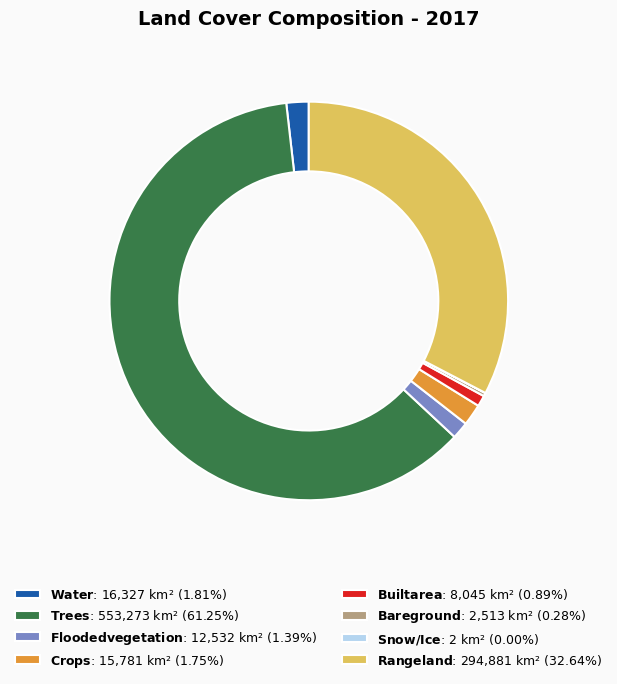

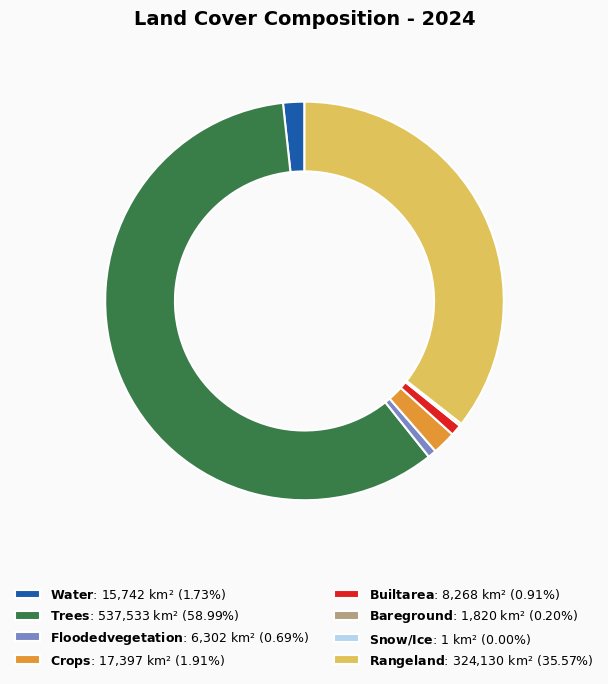

In [8]:
datasets = [(c17, "2017"), (c24, "2024")]

for df, year in datasets:
    fig, ax = plt.subplots(figsize=(10, 7))
    
    total_area = df["area_km2"].sum()
    labels_with_pct = [
        f"$\\bf{{{name.replace('/', ' / ')}}}$: {val:,.0f} km² ({(val/total_area)*100:.2f}%)" 
        for name, val in zip(df["class_name"], df["area_km2"])
    ]
    
    colors = [CLASS_COLORS.get(name, "#999999") for name in df["class_name"]]

    wedges, _ = ax.pie(
        df["area_km2"], 
        colors=colors, 
        startangle=90,
        wedgeprops={"width": 0.35, "edgecolor": "white", "linewidth": 1.5}
    )

    ax.set_title(f"Land Cover Composition - {year}", fontsize=14, fontweight="bold", pad=20)

    ax.legend(
        wedges, 
        labels_with_pct, 
        loc="upper center",
        bbox_to_anchor=(0.5, -0.05),
        ncol=2,    
        fontsize=9, 
        frameon=False
    )

    plt.tight_layout()
    
    save_path = FIGURES / f"donut_final_{year}.png"
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

---
## 3. Net change per class

In [9]:
# Sort by magnitude for visual clarity
comp_sorted = comp.sort_values("change_km2")

fig = px.bar(
    comp_sorted, x="change_km2", y="class_name", orientation="h",
    color=comp_sorted["change_km2"].apply(lambda v: "Loss" if v < 0 else "Gain"),
    color_discrete_map={"Loss": "#B83230", "Gain": "#2D7D46"},
    labels={"change_km2": "Net Change (km²)", "class_name": "", "color": ""}
)
fig.update_layout(template="plotly_white", showlegend=True, title=dict(
        text="<b>Net Land Cover Change — 2017 to 2024</b>",
        x=0.5,
        xanchor="center",
    ))
fig.show()

---
## 4. Transition matrix heatmap

In [10]:
# Use log scale but show readable values

matrix_float = matrix.copy().astype(float)
matrix_log = matrix_float.replace(0, np.nan).apply(np.log10)

# Format values 
text_matrix = matrix_float.map(
    lambda v: f"{v:,.0f}" if v > 0 else "0"
)

# Custom hover text
hover_matrix = [
    [
        f"From: {matrix_float.index[i]}<br>"
        f"To: {matrix_float.columns[j]}<br>"
        f"Area: {matrix_float.iloc[i, j]:,.0f} km²"
        for j in range(len(matrix_float.columns))
    ]
    for i in range(len(matrix_float.index))
]

fig = px.imshow(
    matrix_log,
    color_continuous_scale="YlOrRd",
    labels={"x": "2024", "y": "2017"},

    
    aspect="auto",
)

fig.update_traces(
    text=text_matrix.values,
    texttemplate="%{text}",
    textfont_size=9,
    hovertext=hover_matrix,
    hovertemplate="%{hovertext}<extra></extra>",
)

# Colorbar with readable tick labels instead of raw log values
fig.update_layout(
    template="plotly_white",
    title=dict(
        text="<b>Transition Matrix (2017 → 2024)</b>",
        x=0.5,
        xanchor="center",
    ),
    width=800, height=630,
    coloraxis_colorbar=dict(
        title=dict(
            text="<b>Area (km²)</b>",
            side="right",
        ),
        tickvals=[0, 1, 2, 3, 4, 5, np.log10(510000)],
        ticktext=["1", "10", "100", "1000", "10k", "100k", "510k"],
        len=0.75
    ),
)

fig.show()

---
## 5. Sankey diagram — major class-to-class flows

Showing only transitions above a minimum threshold.

In [11]:
# Build flow data from the transition matrix
# Only off-diagonal flows (actual transitions, not persistence)
flows = []
for src_class in matrix.index:
    for dst_class in matrix.columns:
        if src_class == dst_class:
            continue
        val = matrix.loc[src_class, dst_class]
        if val > 0:
            flows.append({"source": src_class, "target": dst_class, "value": val})

flows_df = pd.DataFrame(flows)

# Keep only the top flows
threshold = flows_df["value"].quantile(0.50)
flows_df = flows_df[flows_df["value"] >= threshold].copy()

print(f"Showing {len(flows_df)} flows above {threshold:,.0f} km²")
flows_df.sort_values("value", ascending=False).head(10)

Showing 27 flows above 102 km²


,source,target,value
13,Trees,Rangeland,40079.7459
47,Rangeland,Trees,16178.5592
49,Rangeland,Crops,6229.9107
20,Flooded vegetation,Rangeland,6110.1757
26,Crops,Rangeland,4583.1591
15,Flooded vegetation,Trees,1300.8587
40,Bare ground,Rangeland,966.4992
48,Rangeland,Flooded vegetation,919.5366
22,Crops,Trees,808.2041
9,Trees,Crops,710.3789


In [12]:
# Build node list: source nodes (2017) on left, target nodes (2024) on right
source_labels = [f"{s} (2017)" for s in flows_df["source"].unique()]
target_labels = [f"{t} (2024)" for t in flows_df["target"].unique()]
all_labels = source_labels + target_labels

# Map names to indices
src_map = {name: i for i, name in enumerate(source_labels)}
tgt_map = {name: i for i, name in enumerate(target_labels, start=len(source_labels))}

# Node colors
node_colors = (
    [CLASS_COLORS.get(s, "#AAAAAA") for s in flows_df["source"].unique()] +
    [CLASS_COLORS.get(t, "#AAAAAA") for t in flows_df["target"].unique()]
)

# Link colors (semi-transparent source color)
def hex_to_rgba(hex_color, alpha=0.35):
    h = hex_color.lstrip("#")
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return f"rgba({r},{g},{b},{alpha})"

link_sources = [src_map[f"{row.source} (2017)"] for row in flows_df.itertuples()]
link_targets = [tgt_map[f"{row.target} (2024)"] for row in flows_df.itertuples()]
link_values = flows_df["value"].tolist()
link_colors = [
    hex_to_rgba(CLASS_COLORS.get(row.source, "#AAAAAA"))
    for row in flows_df.itertuples()
]

fig = go.Figure(go.Sankey(
    node=dict(
        pad=20, thickness=25,
        label=all_labels,
        color=node_colors,
    ),
    link=dict(
        source=link_sources,
        target=link_targets,
        value=link_values,
        color=link_colors,
    ),
))

fig.update_layout(
    title=dict(
        text="<b>Land Cover Transitions — 2017 to 2024</b>",
        x=0.5,
        xanchor="center",
    ),
    template="plotly_white",
    font_size=12,
    width=900, height=600,
)
fig.show()

---
## 6. Summary table


In [13]:
summary = comp[[
    "class_name", "area_km2_2017", "area_km2_2024",
    "change_km2", "change_pct"
]].copy()

summary.columns = ["Class", "2017 (km²)", "2024 (km²)", "Change (km²)", "Change (%)"]
summary = summary.sort_values("Change (km²)")

# Styling table
display(
    summary.style
    .format({"2017 (km²)": "{:,.0f}", "2024 (km²)": "{:,.0f}",
             "Change (km²)": "{:+,.0f}", "Change (%)": "{:+.1f}%"})
    .bar(subset=["Change (km²)"], align="zero",
         color=["#B83230", "#2D7D46"])
    .set_caption("Land Cover Change — Venezuela 2017 to 2024")
)

,Class,2017 (km²),2024 (km²),Change (km²),Change (%)
1,Trees,"553,273","537,533","-15,740",-2.8%
2,Flooded vegetation,"12,532","6,302","-6,229",-49.7%
5,Bare ground,"2,513","1,820",-693,-27.6%
0,Water,"16,327","15,742",-584,-3.6%
6,Snow/Ice,2,1,-1,-43.1%
4,Built area,"8,045","8,268",+223,+2.8%
3,Crops,"15,781","17,397","+1,616",+10.2%
8,Rangeland,"294,881","324,130","+29,250",+9.9%
